In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
data = pd.read_csv('student_ml_dataset.csv')
print(data)

    student_id  weekly_self_study_hours  attendance_percentage  \
0            1                        5                     70   
1            2                        8                     85   
2            3                        2                     60   
3            4                       10                     90   
4            5                        6                     75   
5            6                        1                     50   
6            7                        9                     88   
7            8                        4                     65   
8            9                        7                     80   
9           10                        3                     58   
10          11                       11                     92   
11          12                        2                     55   
12          13                        6                     78   
13          14                        8                     82   
14        

In [20]:
# Features
X = data[['weekly_self_study_hours','attendance_percentage','class_participation','previous_score']]

# Convert score to PASS/FAIL label
y = data['total_score'].apply(lambda x: 1 if x >= 50 else 0)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Predicted Labels:", y_pred)

Predicted Labels: [1 1 1 1]


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load dataset
data = pd.read_csv('student_ml_dataset.csv')

# Features
X = data[['weekly_self_study_hours',
          'attendance_percentage',
          'class_participation',
          'previous_score']]

# Binary target
y = data['total_score'].apply(lambda x: 1 if x >= 50 else 0)

# Train model
model = LogisticRegression()
model.fit(X, y)

# User input
study_hours = float(input("Enter weekly study hours: "))
attendance = float(input("Enter attendance percentage: "))
participation = float(input("Enter class participation (0-10): "))
previous = float(input("Enter previous score: "))

# Convert to DataFrame
new_data = pd.DataFrame({
    'weekly_self_study_hours': [study_hours],
    'attendance_percentage': [attendance],
    'class_participation': [participation],
    'previous_score': [previous]
})

# 🔥 Probability output
prob = model.predict_proba(new_data)

# Class prediction
prediction = model.predict(new_data)

print("\n🎯 Probability of Passing:", prob[0][1])
print("🎯 Predicted Class (0=Fail, 1=Pass):", prediction[0])


🎯 Probability of Passing: 3.642946990229838e-07
🎯 Predicted Class (0=Fail, 1=Pass): 0


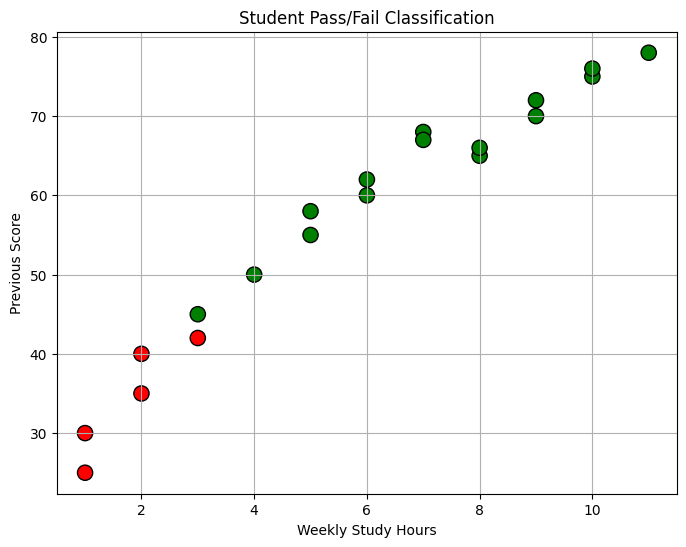

In [22]:
# Load dataset
df = pd.read_csv("student_ml_dataset.csv")

# Features
X = df[['weekly_self_study_hours',
        'attendance_percentage',
        'class_participation',
        'previous_score']]

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Scatter plot
plt.figure(figsize=(8,6))

colors = ['red' if i == 0 else 'green' for i in y]

plt.scatter(df['weekly_self_study_hours'],
            df['previous_score'],
            c=colors,
            s=120,
            edgecolor='black')

plt.xlabel("Weekly Study Hours")
plt.ylabel("Previous Score")
plt.title("Student Pass/Fail Classification")

plt.grid(True)

plt.show()